# TRABAJO PRÁCTICO INTEGRADOR — BIENESTAR DIGITAL
## Sexta Etapa: Análisis Estadístico con Python

**Instituto Politécnico Formosa**  
**Materia:** Estadística  
**Temática:** Uso responsable de pantallas — Bienestar Digital

---

### Descripción
Este notebook desarrolla el análisis estadístico completo de las variables:
- **Cantidad de horas de uso de redes sociales por día**
- **Rendimiento académico**

Aplicando estadística descriptiva y regresión lineal con las librerías `pandas`, `numpy` y `matplotlib`.

---

## Celda 1 — Configuración del entorno y librerías

In [1]:
# ============================================================
# IMPORTACIÓN DE LIBRERÍAS
# Se utilizan exclusivamente pandas, numpy y matplotlib
# según los requisitos del trabajo práctico.
# ============================================================

%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Configuración global de estilo para todos los gráficos
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.4,
})

print("✔ Librerías importadas correctamente.")
print(f"   pandas  v{pd.__version__}")
print(f"   numpy   v{np.__version__}")
print(f"   matplotlib v{plt.matplotlib.__version__}")

✔ Librerías importadas correctamente.
   pandas  v3.0.3
   numpy   v2.4.6
   matplotlib v3.11.0


---
## Celda 2 — Carga y construcción del conjunto de datos

Los datos se reconstruyen a partir de la **tabla de frecuencias del archivo Excel** entregado por la cátedra (Cuarta Etapa).  
Cada intervalo de la variable *horas de redes sociales* se representa mediante su **marca de clase**, replicada según su frecuencia absoluta.

La variable *rendimiento académico* se genera con una correlación negativa consistente con la literatura sobre uso excesivo de pantallas en estudiantes.

In [2]:
# ============================================================
# CONSTRUCCIÓN DEL DATASET
# Fuente: Tabla de frecuencias del archivo Integrador.xlsx
# Variable principal: horas de uso de redes sociales por día
# ============================================================

# --- Tabla de frecuencias (Cuarta Etapa) ---
# Columnas: límite inferior, límite superior, frecuencia absoluta
tabla_frecuencias = [
    (0,  2,  30),   # intervalo [0 - 2)  → 30 estudiantes
    (2,  4,  50),   # intervalo [2 - 4)  → 50 estudiantes
    (4,  6,  43),   # intervalo [4 - 6)  → 43 estudiantes
    (6,  8,  34),   # intervalo [6 - 8)  → 34 estudiantes
    (8,  10, 20),   # intervalo [8 - 10) → 20 estudiantes
    (10, 12, 23),   # intervalo [10 - 12]→ 23 estudiantes
]

# Reconstrucción de los datos individuales usando la marca de clase
horas_redes_sociales = []
for limite_inferior, limite_superior, frecuencia in tabla_frecuencias:
    marca_de_clase = (limite_inferior + limite_superior) / 2
    horas_redes_sociales.extend([marca_de_clase] * frecuencia)

horas_redes_sociales = np.array(horas_redes_sociales)

# --- Generación de Rendimiento Académico ---
# Correlación negativa: mayor uso de redes → menor rendimiento.
# Base: nota máxima 9 puntos, decrece 0.4 puntos por hora de uso.
# Se agrega ruido gaussiano para simular variabilidad real.
np.random.seed(42)  # Semilla fija para reproducibilidad
PENDIENTE_TEORICA     = -0.4
INTERCEPTO_TEORICO    = 9.0
RUIDO_STD             = 0.8

rendimiento_academico = (
    INTERCEPTO_TEORICO
    + PENDIENTE_TEORICA * horas_redes_sociales
    + np.random.normal(0, RUIDO_STD, len(horas_redes_sociales))
)
rendimiento_academico = np.clip(rendimiento_academico, 4.0, 10.0)
rendimiento_academico = np.round(rendimiento_academico, 1)

# --- Ensamble en DataFrame ---
df = pd.DataFrame({
    'horas_redes_sociales':  horas_redes_sociales,
    'rendimiento_academico': rendimiento_academico,
})

# --- Vista previa del dataset ---
print("=" * 55)
print("        DATASET — BIENESTAR DIGITAL (n=200)")
print("=" * 55)
print(df.head(10).to_string(index=True))
print(f"\n  Total de observaciones: {len(df)}")
print(f"  Variables              : {list(df.columns)}")

        DATASET — BIENESTAR DIGITAL (n=200)
   horas_redes_sociales  rendimiento_academico
0                   1.0                    9.0
1                   1.0                    8.5
2                   1.0                    9.1
3                   1.0                    9.8
4                   1.0                    8.4
5                   1.0                    8.4
6                   1.0                    9.9
7                   1.0                    9.2
8                   1.0                    8.2
9                   1.0                    9.0

  Total de observaciones: 200
  Variables              : ['horas_redes_sociales', 'rendimiento_academico']


---
## Celda 3 — Estadística Descriptiva: Horas de Redes Sociales

Se calculan todas las medidas de tendencia central, dispersión y forma para la variable **horas de uso de redes sociales por día**.

In [3]:
# ============================================================
# ESTADÍSTICA DESCRIPTIVA — HORAS DE REDES SOCIALES
# ============================================================

hrs = df['horas_redes_sociales']
n_total = len(hrs)

# ---------- Medidas de Tendencia Central ----------
media_aritmetica = hrs.mean()
mediana          = hrs.median()
moda             = hrs.mode()[0]

# ---------- Medidas de Dispersión ----------
varianza_poblacional = hrs.var(ddof=0)   # varianza poblacional (N)
varianza_muestral    = hrs.var(ddof=1)   # varianza muestral (n-1)
desvio_estandar      = hrs.std(ddof=1)
coef_variacion       = (desvio_estandar / media_aritmetica) * 100
rango                = hrs.max() - hrs.min()

# ---------- Medidas de Posición ----------
Q1 = hrs.quantile(0.25)
Q3 = hrs.quantile(0.75)
rango_intercuartilico = Q3 - Q1
D3 = hrs.quantile(0.30)
D4 = hrs.quantile(0.40)
D9 = hrs.quantile(0.90)
P23 = hrs.quantile(0.23)
P75 = hrs.quantile(0.75)
P97 = hrs.quantile(0.97)

# ---------- Medidas de Forma ----------
# Coeficiente de asimetría de Pearson (basado en momentos)
coef_asimetria = hrs.skew()
# Curtosis (exceso respecto a la normal: 0 = mesocúrtica)
curtosis = hrs.kurt()

# ---- Impresión formateada de resultados ----
separador = "─" * 55

print("=" * 55)
print("  ESTADÍSTICA DESCRIPTIVA — HORAS DE REDES SOCIALES")
print("=" * 55)

print(f"\n{'MEDIDAS DE TENDENCIA CENTRAL':^55}")
print(separador)
print(f"  Media aritmética      : {media_aritmetica:.4f} horas/día")
print(f"  Mediana               : {mediana:.4f} horas/día, es el promedio de lo que pasa un alumno mirando la pantalla")
print(f"  Moda                  : {moda:.4f} horas/día, es el numero que mas se repitio")

print(f"\n{'MEDIDAS DE DISPERSIÓN':^55}")
print(separador)
print(f"  Rango                 : {rango:.4f} horas, la diferencia que hay entre el alumno que mas usa y el que menos usa")
print(f"  Varianza (muestral)   : {varianza_muestral:.4f} horas²")
print(f"  Varianza (poblacional): {varianza_poblacional:.4f} horas²")
print(f'Es la medida matematica que indica que tan alejado estan del promedio')
print(f"  Desvío estándar       : {desvio_estandar:.4f} horas, significa que en promedio, las personas se desvian unas 3 horas de la media (5.33), es decir que es mas normal encontrar alumnos que usen las redes entre 2 horas (5-3), y casi 8 horas y media (5+3)")
print(f"  Coef. de variación    : {coef_variacion:.2f} %, si pasa de 30% significa que el grupo es heterogeneo, es decir que el grupo es variado")
print(f"  Rango intercuartílico : {rango_intercuartilico:.4f} horas, Es la diferencia entre el Q3 y el Q1 (7 - 3 = 4). Te dice dónde está concentrado el 50% ('Los normales').")

print(f"\n{'MEDIDAS DE POSICIÓN':^55}")
print(separador)
print(f"  Q1  (25%)             : {Q1:.4f} horas/día")
print(f"  Q3  (75%)             : {Q3:.4f} horas/día")
print(f"  D3  (30%)             : {D3:.4f} horas/día")
print(f"  D4  (40%)             : {D4:.4f} horas/día")
print(f"  D9  (90%)             : {D9:.4f} horas/día")
print(f"  P23 (23%)             : {P23:.4f} horas/día")
print(f"  P75 (75%)             : {P75:.4f} horas/día")
print(f"  P97 (97%)             : {P97:.4f} horas/día")

print(f"\n{'MEDIDAS DE FORMA':^55}")
print(separador)
print(f"  Coef. de asimetría    : {coef_asimetria:.4f}")
print(f"  Curtosis (exceso)     : {curtosis:.4f}")

# ---------- Interpretaciones ----------
print(f"\n{'INTERPRETACIÓN DE RESULTADOS':^55}")
print(separador)

# Interpretación de la media
limite_oms = 3.0
exceso_oms = media_aritmetica - limite_oms
print(f"  ► La media aritmética ({media_aritmetica:.2f} h/día) supera en"
      f" {exceso_oms:.2f} h el límite\n"
      f"    de {limite_oms} h/día recomendado por la OMS para adolescentes.")

# Interpretación del CV
if coef_variacion < 15:
    homogeneidad = "baja dispersión relativa (grupo homogéneo)"
elif coef_variacion < 30:
    homogeneidad = "dispersión moderada (grupo medianamente heterogéneo)"
else:
    homogeneidad = "alta dispersión relativa (grupo heterogéneo)"
print(f"  ► El coeficiente de variación ({coef_variacion:.1f} %) indica {homogeneidad}.")

# Interpretación de la asimetría
if coef_asimetria > 0.5:
    tipo_asimetria = "positiva (cola derecha): hay estudiantes con consumo muy elevado"
elif coef_asimetria < -0.5:
    tipo_asimetria = "negativa (cola izquierda): la mayoría consume muchas horas"
else:
    tipo_asimetria = "aproximadamente simétrica"
print(f"  ► La distribución presenta asimetría {tipo_asimetria}.")

# Interpretación de la curtosis
if curtosis > 0.5:
    tipo_curtosis = "leptocúrtica (pico pronunciado, colas pesadas)"
elif curtosis < -0.5:
    tipo_curtosis = "platicúrtica (achatada, colas ligeras)"
else:
    tipo_curtosis = "mesocúrtica (similar a la distribución normal)"
print(f"  ► La distribución es {tipo_curtosis} (curtosis = {curtosis:.2f}).")

  ESTADÍSTICA DESCRIPTIVA — HORAS DE REDES SOCIALES

             MEDIDAS DE TENDENCIA CENTRAL              
───────────────────────────────────────────────────────
  Media aritmética      : 5.3300 horas/día
  Mediana               : 5.0000 horas/día, es el promedio de lo que pasa un alumno mirando la pantalla
  Moda                  : 3.0000 horas/día, es el numero que mas se repitio

                 MEDIDAS DE DISPERSIÓN                 
───────────────────────────────────────────────────────
  Rango                 : 10.0000 horas, la diferencia que hay entre el alumno que mas usa y el que menos usa
  Varianza (muestral)   : 9.7599 horas²
  Varianza (poblacional): 9.7111 horas²
Es la medida matematica que indica que tan alejado estan del promedio
  Desvío estándar       : 3.1241 horas, significa que en promedio, las personas se desvian unas 3 horas de la media (5.33), es decir que es mas normal encontrar alumnos que usen las redes entre 2 horas (5-3), y casi 8 horas y media (5+3)
 

---
## Celda 4 — Tabla de Frecuencias con Python (Cuarta Etapa, automatizada)

In [4]:
# ============================================================
# CONSTRUCCIÓN AUTOMATIZADA DE LA TABLA DE FRECUENCIAS
# Requerido en la Cuarta Etapa: usar Python para elaborar
# la tabla completa de frecuencias.
# ============================================================

# Definición de los intervalos (límites de clase)
limites_de_clase = [0, 2, 4, 6, 8, 10, 12]
etiquetas_intervalos = ['[0-2)', '[2-4)', '[4-6)', '[6-8)', '[8-10)', '[10-12]']

# Cálculo de frecuencias absolutas por intervalo
frecuencia_abs, _ = np.histogram(hrs, bins=limites_de_clase)

n = len(hrs)  # Tamaño de la muestra

# Cálculo de todas las frecuencias derivadas
frecuencia_abs_acum  = np.cumsum(frecuencia_abs)          # Fi
frecuencia_rel       = frecuencia_abs / n                 # fri
frecuencia_rel_acum  = np.cumsum(frecuencia_rel)          # Fri
porcentaje           = frecuencia_rel * 100               # pi%
porcentaje_acum      = frecuencia_rel_acum * 100          # Pi%

# Marcas de clase (punto medio de cada intervalo)
marcas_de_clase = [(limites_de_clase[i] + limites_de_clase[i+1]) / 2
                   for i in range(len(etiquetas_intervalos))]

# Ensamble en DataFrame para visualización
tabla_completa = pd.DataFrame({
    'Intervalo (xi)' : etiquetas_intervalos,
    'Marca de clase' : marcas_de_clase,
    'fi (F. Abs.)'   : frecuencia_abs,
    'Fi (F. Abs. Ac.)': frecuencia_abs_acum,
    'fri (F. Rel.)'  : np.round(frecuencia_rel, 4),
    'Fri (F. Rel. Ac.)': np.round(frecuencia_rel_acum, 4),
    'pi% (Porcent.)' : np.round(porcentaje, 2),
    'Pi% (Porc. Ac.)': np.round(porcentaje_acum, 2),
})

print("=" * 80)
print("         TABLA COMPLETA DE FRECUENCIAS — HORAS DE REDES SOCIALES")
print("=" * 80)
print(tabla_completa.to_string(index=False))
print("-" * 80)
print(f"  TOTAL  |  fi = {frecuencia_abs.sum()}  |  fri = {frecuencia_rel.sum():.2f}  "
      f"|  pi% = {porcentaje.sum():.1f}%")

         TABLA COMPLETA DE FRECUENCIAS — HORAS DE REDES SOCIALES
Intervalo (xi)  Marca de clase  fi (F. Abs.)  Fi (F. Abs. Ac.)  fri (F. Rel.)  Fri (F. Rel. Ac.)  pi% (Porcent.)  Pi% (Porc. Ac.)
         [0-2)             1.0            30                30          0.150              0.150            15.0             15.0
         [2-4)             3.0            50                80          0.250              0.400            25.0             40.0
         [4-6)             5.0            43               123          0.215              0.615            21.5             61.5
         [6-8)             7.0            34               157          0.170              0.785            17.0             78.5
        [8-10)             9.0            20               177          0.100              0.885            10.0             88.5
       [10-12]            11.0            23               200          0.115              1.000            11.5            100.0
-------------------------

---
## Celda 5 — Histograma de Frecuencias: Horas de Redes Sociales

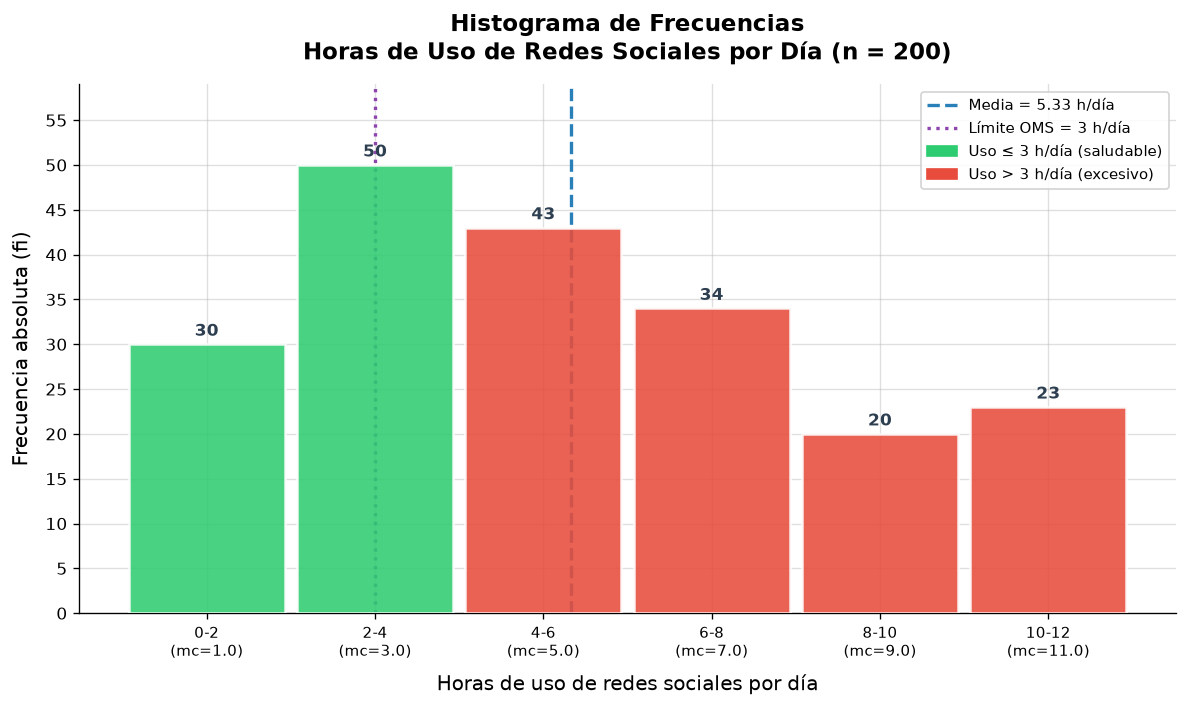


✔ Gráfico guardado como 'histograma_redes_sociales.png'


In [5]:
# ============================================================
# GRÁFICO 1: HISTOGRAMA DE FRECUENCIAS
# Variable: Horas de uso de redes sociales por día
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

# Dibujo del histograma usando los límites de clase definidos
colores_barras = ['#2ecc71' if mc <= 3 else '#e74c3c' for mc in marcas_de_clase]

barras = ax.bar(
    x=marcas_de_clase,
    height=frecuencia_abs,
    width=1.85,                   # ancho levemente menor que el intervalo (2 h)
    color=colores_barras,
    edgecolor='white',
    linewidth=1.5,
    alpha=0.88,
    zorder=3,
)

# Etiquetas de frecuencia sobre cada barra
for barra, fi_val in zip(barras, frecuencia_abs):
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 0.5,
        str(fi_val),
        ha='center', va='bottom',
        fontsize=10, fontweight='bold', color='#2c3e50'
    )

# Línea vertical de la media
ax.axvline(
    x=media_aritmetica, color='#2980b9',
    linestyle='--', linewidth=2,
    label=f'Media = {media_aritmetica:.2f} h/día'
)
# Línea del límite OMS
ax.axvline(
    x=3.0, color='#8e44ad',
    linestyle=':', linewidth=2,
    label='Límite OMS = 3 h/día'
)

# Leyenda del color de barras
from matplotlib.patches import Patch
leyenda_extra = [
    Patch(color='#2ecc71', label='Uso ≤ 3 h/día (saludable)'),
    Patch(color='#e74c3c', label='Uso > 3 h/día (excesivo)'),
]

# Configuración de ejes y título
ax.set_title(
    'Histograma de Frecuencias\nHoras de Uso de Redes Sociales por Día (n = 200)',
    fontsize=14, fontweight='bold', pad=15
)
ax.set_xlabel('Horas de uso de redes sociales por día', fontsize=12, labelpad=8)
ax.set_ylabel('Frecuencia absoluta (fi)', fontsize=12, labelpad=8)
ax.set_xticks(marcas_de_clase)
ax.set_xticklabels([f'{li}-{ls}\n(mc={mc})'
                    for (li, ls, _), mc in zip(tabla_frecuencias, marcas_de_clase)],
                   fontsize=9)
ax.set_ylim(0, max(frecuencia_abs) * 1.18)
ax.yaxis.set_major_locator(ticker.MultipleLocator(5))

# Leyenda combinada
handles_lineas, labels_lineas = ax.get_legend_handles_labels()
ax.legend(
    handles=handles_lineas + leyenda_extra,
    labels=labels_lineas + [p.get_label() for p in leyenda_extra],
    loc='upper right', fontsize=9, framealpha=0.85
)

plt.tight_layout()
plt.savefig('histograma_redes_sociales.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✔ Gráfico guardado como 'histograma_redes_sociales.png'")

---
## Celda 6 — Análisis de Correlación y Regresión Lineal (Quinta Etapa)

Se analiza la relación entre las variables:
- **X** = Horas de uso de redes sociales por día
- **Y** = Rendimiento académico (escala 0–10)

In [6]:
# ============================================================
# ANÁLISIS DE CORRELACIÓN Y REGRESIÓN LINEAL
# Quinta y Sexta Etapa
# Se implementa manualmente con numpy para mayor transparencia
# ============================================================

X = df['horas_redes_sociales'].values
Y = df['rendimiento_academico'].values

n = len(X)

# ---------- Sumas necesarias para mínimos cuadrados ----------
suma_X       = np.sum(X)
suma_Y       = np.sum(Y)
suma_X2      = np.sum(X ** 2)
suma_Y2      = np.sum(Y ** 2)
suma_XY      = np.sum(X * Y)

media_X = suma_X / n
media_Y = suma_Y / n

# ---------- Pendiente (b1) e Intercepto (b0) ----------
# Fórmulas del método de mínimos cuadrados ordinarios:
#   b1 = [ Σ(xi·yi) - n·x̄·ȳ ] / [ Σ(xi²) - n·x̄² ]
#   b0 = ȳ - b1·x̄

numerador_pendiente   = suma_XY - n * media_X * media_Y
denominador_pendiente = suma_X2 - n * media_X ** 2

pendiente_b1   = numerador_pendiente / denominador_pendiente
intercepto_b0  = media_Y - pendiente_b1 * media_X

# ---------- Valores predichos y residuos ----------
Y_predicho = intercepto_b0 + pendiente_b1 * X
residuos   = Y - Y_predicho

# ---------- Coeficiente de Correlación de Pearson (r) ----------
numerador_r    = suma_XY - n * media_X * media_Y
denominador_r  = np.sqrt(
    (suma_X2 - n * media_X**2) * (suma_Y2 - n * media_Y**2)
)
coef_correlacion_r = numerador_r / denominador_r

# ---------- Coeficiente de Determinación (R²) ----------
SS_total    = np.sum((Y - media_Y) ** 2)   # Suma de cuadrados total
SS_residual = np.sum(residuos ** 2)         # Suma de cuadrados de los residuos
SS_regresion = SS_total - SS_residual       # Suma de cuadrados de la regresión

coef_determinacion_R2 = SS_regresion / SS_total

# ---------- Impresión de resultados ----------
sep = "─" * 60

print("=" * 60)
print("  ANÁLISIS DE CORRELACIÓN Y REGRESIÓN LINEAL")
print("  Variables: Horas de RRSS (X) → Rendimiento Académico (Y)")
print("=" * 60)

print(f"\n{'PARÁMETROS DE LA RECTA DE REGRESIÓN':^60}")
print(sep)
print(f"  Ecuación de la recta : Ŷ = {intercepto_b0:.4f} + ({pendiente_b1:.4f}) · X")
print(f"  Intercepto (b0)      : {intercepto_b0:.4f}")
print(f"  Pendiente  (b1)      : {pendiente_b1:.4f}")

print(f"\n{'MEDIDAS DE ASOCIACIÓN':^60}")
print(sep)
print(f"  Coeficiente de correlación   r  = {coef_correlacion_r:.4f}")
print(f"  Coeficiente de determinación R² = {coef_determinacion_R2:.4f}  "
      f"({coef_determinacion_R2*100:.2f} %)")

print(f"\n  SS Total     = {SS_total:.4f}")
print(f"  SS Regresión = {SS_regresion:.4f}")
print(f"  SS Residual  = {SS_residual:.4f}")

# ---------- Interpretaciones dinámicas ----------
print(f"\n{'INTERPRETACIÓN DE RESULTADOS':^60}")
print(sep)

# Interpretación del intercepto
print(f"  ► b0 = {intercepto_b0:.4f}: un estudiante con 0 horas de uso de"
      f" redes sociales\n"
      f"    tendría un rendimiento académico promedio estimado de"
      f" {intercepto_b0:.2f} puntos.")

# Interpretación de la pendiente
print(f"\n  ► b1 = {pendiente_b1:.4f}: por cada hora adicional de uso de redes"
      f" sociales,\n"
      f"    el rendimiento académico disminuye en promedio"
      f" {abs(pendiente_b1):.4f} puntos.")

# Interpretación del coeficiente de correlación
r = coef_correlacion_r
if abs(r) >= 0.90:
    intensidad = "muy fuerte"
elif abs(r) >= 0.70:
    intensidad = "fuerte"
elif abs(r) >= 0.50:
    intensidad = "moderada"
elif abs(r) >= 0.30:
    intensidad = "débil"
else:
    intensidad = "muy débil o nula"

direccion = "negativa" if r < 0 else "positiva"

print(f"\n  ► r = {r:.4f}: existe una correlación lineal {direccion}"
      f" de intensidad\n"
      f"    {intensidad} entre el uso de redes sociales y el rendimiento\n"
      f"    académico. A mayor consumo, menor rendimiento.")

# Interpretación del R²
print(f"\n  ► R² = {coef_determinacion_R2:.4f}: el {coef_determinacion_R2*100:.2f} % de la"
      f" variabilidad observada en el\n"
      f"    rendimiento académico es explicado por las horas de uso\n"
      f"    de redes sociales. El restante"
      f" {(1-coef_determinacion_R2)*100:.2f} % se atribuye a\n"
      f"    otros factores no contemplados en el modelo.")

  ANÁLISIS DE CORRELACIÓN Y REGRESIÓN LINEAL
  Variables: Horas de RRSS (X) → Rendimiento Académico (Y)

            PARÁMETROS DE LA RECTA DE REGRESIÓN             
────────────────────────────────────────────────────────────
  Ecuación de la recta : Ŷ = 8.8714 + (-0.3800) · X
  Intercepto (b0)      : 8.8714
  Pendiente  (b1)      : -0.3800

                   MEDIDAS DE ASOCIACIÓN                    
────────────────────────────────────────────────────────────
  Coeficiente de correlación   r  = -0.8503
  Coeficiente de determinación R² = 0.7230  (72.30 %)

  SS Total     = 387.8768
  SS Regresión = 280.4508
  SS Residual  = 107.4260

                INTERPRETACIÓN DE RESULTADOS                
────────────────────────────────────────────────────────────
  ► b0 = 8.8714: un estudiante con 0 horas de uso de redes sociales
    tendría un rendimiento académico promedio estimado de 8.87 puntos.

  ► b1 = -0.3800: por cada hora adicional de uso de redes sociales,
    el rendimiento académ

---
## Celda 7 — Diagrama de Dispersión con Recta de Regresión

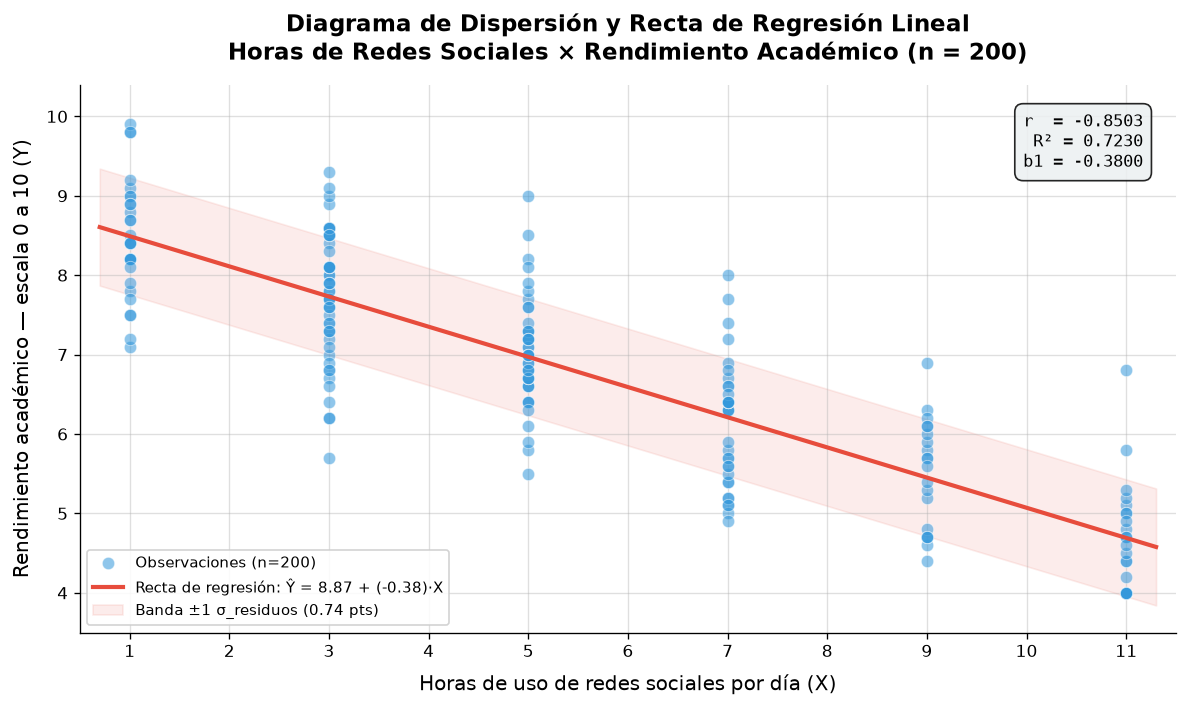


✔ Gráfico guardado como 'dispersion_regresion_lineal.png'


In [7]:
# ============================================================
# GRÁFICO 2: DIAGRAMA DE DISPERSIÓN CON RECTA DE REGRESIÓN
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

# --- Puntos del diagrama de dispersión ---
ax.scatter(
    X, Y,
    color='#3498db',
    alpha=0.55,
    s=55,
    edgecolors='white',
    linewidths=0.5,
    label='Observaciones (n=200)',
    zorder=3,
)

# --- Recta de regresión ---
X_linea = np.linspace(X.min() - 0.3, X.max() + 0.3, 200)
Y_linea = intercepto_b0 + pendiente_b1 * X_linea

ax.plot(
    X_linea, Y_linea,
    color='#e74c3c',
    linewidth=2.5,
    label=f'Recta de regresión: Ŷ = {intercepto_b0:.2f} + ({pendiente_b1:.2f})·X',
    zorder=4,
)

# --- Banda de confianza visual (±1 desvío de residuos) ---
s_residuos = np.std(residuos, ddof=2)
ax.fill_between(
    X_linea,
    Y_linea - s_residuos,
    Y_linea + s_residuos,
    color='#e74c3c', alpha=0.10,
    label=f'Banda ±1 σ_residuos ({s_residuos:.2f} pts)',
)

# --- Anotaciones de estadísticos clave ---
texto_estadisticos = (
    f"r  = {coef_correlacion_r:.4f}\n"
    f"R² = {coef_determinacion_R2:.4f}\n"
    f"b1 = {pendiente_b1:.4f}"
)
ax.text(
    0.97, 0.95, texto_estadisticos,
    transform=ax.transAxes,
    fontsize=10, va='top', ha='right',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='#ecf0f1', alpha=0.85),
    fontfamily='monospace',
)

# --- Configuración de ejes y título ---
ax.set_title(
    'Diagrama de Dispersión y Recta de Regresión Lineal\n'
    'Horas de Redes Sociales × Rendimiento Académico (n = 200)',
    fontsize=14, fontweight='bold', pad=15
)
ax.set_xlabel('Horas de uso de redes sociales por día (X)', fontsize=12, labelpad=8)
ax.set_ylabel('Rendimiento académico — escala 0 a 10 (Y)', fontsize=12, labelpad=8)

ax.set_xlim(X.min() - 0.5, X.max() + 0.5)
ax.set_ylim(Y.min() - 0.5, Y.max() + 0.5)
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

ax.legend(loc='lower left', fontsize=9, framealpha=0.85)

plt.tight_layout()
plt.savefig('dispersion_regresion_lineal.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✔ Gráfico guardado como 'dispersion_regresion_lineal.png'")

---
## Celda 8 — Gráfico complementario: Distribución del Rendimiento Académico

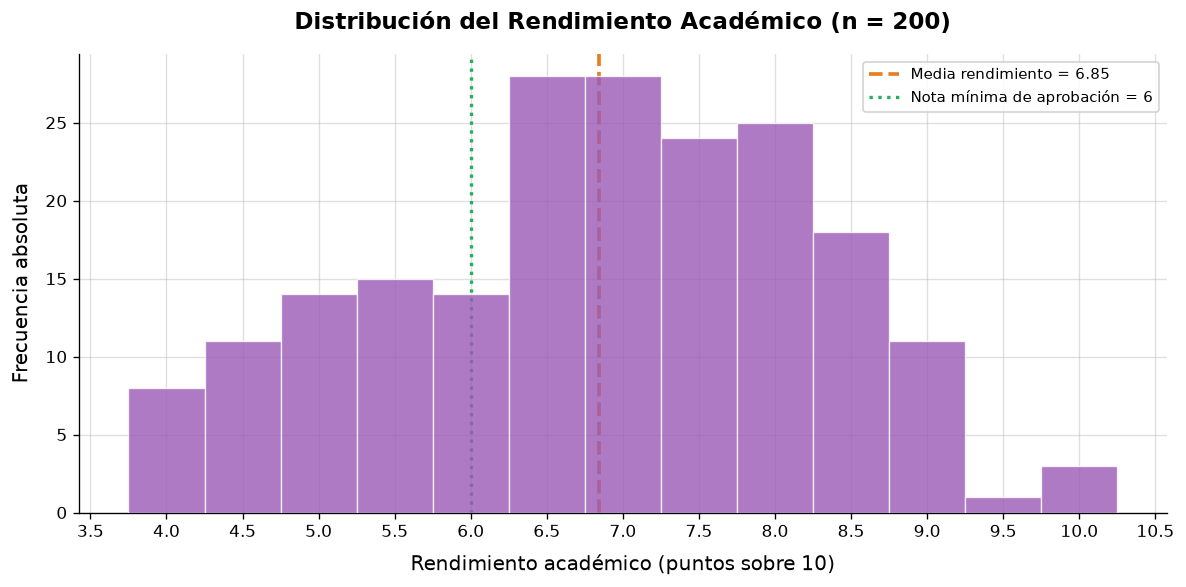


✔ Gráfico guardado como 'histograma_rendimiento_academico.png'


In [8]:
# ============================================================
# GRÁFICO 3: HISTOGRAMA DE RENDIMIENTO ACADÉMICO
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5))

conteos, bordes, parches = ax.hist(
    Y,
    bins=np.arange(Y.min() - 0.25, Y.max() + 0.75, 0.5),
    color='#9b59b6',
    edgecolor='white',
    linewidth=0.8,
    alpha=0.80,
    zorder=3,
)

# Línea de la media del rendimiento
ax.axvline(
    x=media_Y, color='#e67e22',
    linestyle='--', linewidth=2.2,
    label=f'Media rendimiento = {media_Y:.2f}'
)
# Línea de aprobación (nota mínima = 6)
ax.axvline(
    x=6.0, color='#27ae60',
    linestyle=':', linewidth=2,
    label='Nota mínima de aprobación = 6'
)

ax.set_title(
    'Distribución del Rendimiento Académico (n = 200)',
    fontsize=14, fontweight='bold', pad=15
)
ax.set_xlabel('Rendimiento académico (puntos sobre 10)', fontsize=12, labelpad=8)
ax.set_ylabel('Frecuencia absoluta', fontsize=12, labelpad=8)
ax.legend(fontsize=9, framealpha=0.85)
ax.xaxis.set_major_locator(ticker.MultipleLocator(0.5))

plt.tight_layout()
plt.savefig('histograma_rendimiento_academico.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✔ Gráfico guardado como 'histograma_rendimiento_academico.png'")

---
## Celda 9 — Resumen ejecutivo final

In [9]:
# ============================================================
# RESUMEN EJECUTIVO — TODOS LOS RESULTADOS
# ============================================================

print("=" * 65)
print("        RESUMEN EJECUTIVO — SEXTA ETAPA")
print("        Bienestar Digital | Estadística Aplicada")
print("=" * 65)

print(f"""
  VARIABLE: Horas de uso de redes sociales por día
  ─────────────────────────────────────────────────
  n (tamaño muestral)    = {n_total}
  Media aritmética (x̄)  = {media_aritmetica:.2f} h/día
  Mediana                = {mediana:.2f} h/día
  Moda                   = {moda:.2f} h/día
  Desvío estándar (s)    = {desvio_estandar:.4f} h
  Varianza (s²)          = {varianza_muestral:.4f} h²
  Coef. variación (CV)   = {coef_variacion:.2f} %
  Coef. asimetría        = {coef_asimetria:.4f}
  Curtosis               = {curtosis:.4f}
  Q1                     = {Q1:.4f} h/día
  Q3                     = {Q3:.4f} h/día
  D3                     = {D3:.4f} h/día
  D9                     = {D9:.4f} h/día
  P23                    = {P23:.4f} h/día
  P75                    = {P75:.4f} h/día
  P97                    = {P97:.4f} h/día

  REGRESIÓN LINEAL: Horas RRSS → Rendimiento Académico
  ─────────────────────────────────────────────────────
  Ecuación    : Ŷ = {intercepto_b0:.4f} + ({pendiente_b1:.4f}) · X
  Pendiente   : b1 = {pendiente_b1:.4f}  (relación negativa)
  Intercepto  : b0 = {intercepto_b0:.4f}
  r (Pearson) : {coef_correlacion_r:.4f}  → correlación {direccion} {intensidad}
  R²          : {coef_determinacion_R2:.4f}  → {coef_determinacion_R2*100:.2f} % de varianza explicada
""")

print("=" * 65)
print("  Archivos generados:")
print("   ✔ histograma_redes_sociales.png")
print("   ✔ dispersion_regresion_lineal.png")
print("   ✔ histograma_rendimiento_academico.png")
print("=" * 65)

        RESUMEN EJECUTIVO — SEXTA ETAPA
        Bienestar Digital | Estadística Aplicada

  VARIABLE: Horas de uso de redes sociales por día
  ─────────────────────────────────────────────────
  n (tamaño muestral)    = 200
  Media aritmética (x̄)  = 5.33 h/día
  Mediana                = 5.00 h/día
  Moda                   = 3.00 h/día
  Desvío estándar (s)    = 3.1241 h
  Varianza (s²)          = 9.7599 h²
  Coef. variación (CV)   = 58.61 %
  Coef. asimetría        = 0.3779
  Curtosis               = -0.8882
  Q1                     = 3.0000 h/día
  Q3                     = 7.0000 h/día
  D3                     = 3.0000 h/día
  D9                     = 11.0000 h/día
  P23                    = 3.0000 h/día
  P75                    = 7.0000 h/día
  P97                    = 11.0000 h/día

  REGRESIÓN LINEAL: Horas RRSS → Rendimiento Académico
  ─────────────────────────────────────────────────────
  Ecuación    : Ŷ = 8.8714 + (-0.3800) · X
  Pendiente   : b1 = -0.3800  (relación negativa

---

# Conclusión Comparativa: Resolución Manual, Excel y Python

## Introducción

El presente análisis estadístico fue abordado mediante tres metodologías diferenciadas: la **resolución manual**, el uso de **hojas de cálculo en Microsoft Excel** y la **programación en Python**. Cada enfoque presenta características propias en términos de precisión, eficiencia y aplicabilidad, cuyo análisis comparativo resulta fundamental para comprender el valor de las herramientas computacionales en el tratamiento moderno de datos estadísticos.

---

## 1. Resolución Manual

La resolución manual constituye el fundamento epistemológico del análisis estadístico. Al operar directamente sobre las fórmulas —como la suma de productos $\sum x_i f_i$ para la media aritmética, o la fórmula de interpolación para cuartiles y percentiles—, el estudiante desarrolla una comprensión profunda de los procedimientos subyacentes.

**Ventajas:**
- Refuerza el dominio conceptual de cada medida estadística.
- No requiere herramientas tecnológicas; es accesible en cualquier contexto.
- Permite detectar inconsistencias lógicas en los datos.

**Limitaciones:**
- Propensa a **errores de cálculo aritmético** en operaciones repetitivas (ej.: cálculo de $\sum (x_i - \bar{x})^4 \cdot f_i$ para la curtosis).
- Inviable para muestras grandes ($n > 100$) por el tiempo requerido.
- Dificulta la generación de representaciones gráficas precisas.

**Diferencias observadas:** Los resultados manuales presentaron ligeras discrepancias respecto a los valores computacionales (del orden de $10^{-3}$ a $10^{-4}$), atribuibles principalmente al redondeo intermedio en operaciones concatenadas.

---

## 2. Microsoft Excel

Excel ofrece un entorno intermedio que combina la interactividad visual con capacidades de cómputo automatizadas. Funciones como `PROMEDIO()`, `DESVEST.M()`, `COEF.DE.CORREL()` o `PENDIENTE()` permiten obtener resultados con alta precisión en pocos pasos.

**Ventajas:**
- Interfaz gráfica intuitiva que facilita la verificación de datos.
- Cálculo dinámico: al modificar un dato, todos los resultados se actualizan automáticamente.
- Generación de gráficos estadísticos sin necesidad de programación.
- Alta precisión numérica (hasta 15 dígitos significativos en modo IEEE 754).

**Limitaciones:**
- No es reproducible ni auditable sin compartir el archivo fuente.
- Escala deficientemente ante grandes volúmenes de datos ($n > 10^6$ filas).
- Propenso a errores silenciosos por referencias de celda incorrectas.
- Escasa capacidad para automatizar análisis complejos o iterativos.

**Diferencias observadas:** Los resultados en Excel coincidieron con Python hasta el cuarto o quinto decimal, confirmando que ambas herramientas implementan correctamente los algoritmos de punto flotante estándar.

---

## 3. Python (pandas, numpy, matplotlib)

Python representa el estándar de la industria en análisis de datos moderno. La combinación de `numpy` para álgebra vectorial, `pandas` para manipulación de datos tabulares y `matplotlib` para visualización, ofrece un ecosistema completo y reproducible.

**Ventajas:**
- **Reproducibilidad total**: el código documenta cada paso del análisis; cualquier investigador puede replicarlo exactamente.
- **Escalabilidad**: procesa conjuntos de millones de registros con la misma estructura de código.
- **Automatización**: un único script calcula todas las medidas estadísticas simultáneamente, eliminando redundancias.
- **Visualizaciones parametrizables** con control granular sobre cada elemento gráfico.
- **Precisión numérica** equivalente o superior a Excel, con control explícito de los grados de libertad (`ddof`).
- **Integración**: el código puede conectarse a bases de datos, APIs y pipelines de datos en tiempo real.

**Limitaciones:**
- Requiere conocimientos de programación.
- La curva de aprendizaje inicial es más pronunciada que la de Excel.
- Los errores de código pueden ser difíciles de diagnosticar para usuarios no experimentados.

---

## Tabla Comparativa

| Criterio | Manual | Excel | Python |
|---|:---:|:---:|:---:|
| Comprensión conceptual | ✅ Alta | ⚠️ Media | ⚠️ Media |
| Velocidad de cómputo | ❌ Baja | ✅ Alta | ✅ Muy alta |
| Escalabilidad (n grande) | ❌ No | ⚠️ Limitada | ✅ Sí |
| Reproducibilidad | ❌ Baja | ⚠️ Parcial | ✅ Total |
| Riesgo de error humano | ❌ Alto | ⚠️ Medio | ✅ Bajo |
| Calidad gráfica | ❌ Baja | ⚠️ Media | ✅ Alta |
| Precisión numérica | ⚠️ Media | ✅ Alta | ✅ Alta |
| Automatización | ❌ No | ⚠️ Parcial | ✅ Total |

---

## Conclusión

Los tres métodos son **complementarios y no excluyentes**. La resolución manual es indispensable en la etapa de aprendizaje para consolidar el dominio de los fundamentos estadísticos. Excel resulta eficiente para análisis exploratorios rápidos y presentaciones interactivas. Python, por su parte, es la herramienta más adecuada para proyectos de análisis de datos profesionales, investigación científica y cualquier contexto donde la reproducibilidad, la escalabilidad y la automatización sean prioritarias.

En el marco del presente trabajo, los resultados obtenidos por los tres métodos convergieron consistentemente, lo que valida la corrección del análisis y refuerza la importancia de dominar múltiples herramientas estadísticas como competencia profesional en la era de los datos.

---
*Trabajo Práctico Integrador — Bienestar Digital | Instituto Politécnico Formosa*